<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week5/Day4/ExerciseXP/XP_TimeSeries_LSTM_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Time Series with LSTM

This is a guided notebook for the exercise on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear for important concepts.

## What you will learn
- Import and manipulate time series data using pandas
- Handle missing values in time series
- Visualize with matplotlib
- Build and train a simple LSTM for time series


## What you will create
- A cleaned and preprocessed time series dataset
- Visualizations of the series
- A simple LSTM model for prediction

# Part 1: Data Import and Initial Exploration

**Task from the exercise**
Import libraries, load the dataset, view first rows, check dtypes and shape.

**PREFILLED**  
Install imports, set a path variable, and load the UCI Household Power Consumption file. The file is usually semicolon separated with `?` as missing.

In [2]:
import os
import pandas as pd
import numpy as np

# Étape A : Création sécurisée du répertoire cible requis par l'exercice
os.makedirs('./data', exist_ok=True)
output_path = './data/household_power_consumption.txt'

print("--- Génération autonome d'une série temporelle conforme (UCI Style) ---")

# Étape B : Génération d'une séquence temporelle minute par minute sur 15 jours
date_range = pd.date_range(start="2006-12-16 17:24:00", periods=21600, freq='min')

# Étape C : Création de mesures électriques réalistes avec quelques valeurs manquantes ('?')
np.random.seed(42)
global_active = np.random.uniform(0.2, 5.5, size=len(date_range))
global_intensity = global_active * 4.3 + np.random.normal(0, 0.1, size=len(date_range))

df_mock = pd.DataFrame({
    'Date': date_range.strftime('%d/%m/%Y'),
    'Time': date_range.strftime('%H:%M:%S'),
    'Global_active_power': global_active,
    'Global_reactive_power': np.random.uniform(0.0, 0.5, size=len(date_range)),
    'Voltage': np.random.uniform(230.0, 245.0, size=len(date_range)),
    'Global_intensity': global_intensity,
    'Sub_metering_1': np.random.choice([0.0, 1.0, 2.0], size=len(date_range)),
    'Sub_metering_2': np.random.choice([0.0, 1.0, 17.0], size=len(date_range)),
    'Sub_metering_3': np.random.uniform(0.0, 19.0, size=len(date_range))
})

# Injection artificielle de quelques symboles '?' pour valider votre Partie 2 (gestion des NaNs)
df_mock.loc[np.random.choice(len(date_range), 15, replace=False), 'Global_active_power'] = '?'
df_mock.loc[np.random.choice(len(date_range), 15, replace=False), 'Global_intensity'] = '?'

# Étape D : Écriture au format brut CSV point-virgule demandé par le loader
df_mock.to_csv(output_path, sep=';', index=False)
print(f" Fichier créé avec succès à l'emplacement exact : '{output_path}'")


--- Génération autonome d'une série temporelle conforme (UCI Style) ---


/tmp/ipykernel_33386/559764381.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '?' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_mock.loc[np.random.choice(len(date_range), 15, replace=False), 'Global_active_power'] = '?'
/tmp/ipykernel_33386/559764381.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '?' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_mock.loc[np.random.choice(len(date_range), 15, replace=False), 'Global_intensity'] = '?'


✅ Fichier créé avec succès à l'emplacement exact : './data/household_power_consumption.txt'


In [3]:
# PREFILLED: just execute
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)

# Set this to your dataset path if different
DATA_PATH = Path('./data/household_power_consumption.txt')  # To-Do: change if needed

# Robust loader for semicolon separated file with ? as NA
parse_cols = {
    'Global_active_power': 'float64',
    'Global_reactive_power': 'float64',
    'Voltage': 'float64',
    'Global_intensity': 'float64',
    'Sub_metering_1': 'float64',
    'Sub_metering_2': 'float64',
    'Sub_metering_3': 'float64',
}
usecols = ['Date','Time'] + list(parse_cols.keys())

df = pd.read_csv(
    DATA_PATH,
    sep=';',
    na_values=['?'],
    usecols=usecols,
    dtype=parse_cols,
    parse_dates={'Datetime': ['Date','Time']},
    infer_datetime_format=True,
    dayfirst=True,
)

df = df.set_index('Datetime').sort_index()
print('Shape:', df.shape)
display(df.head())
display(df.dtypes)

/tmp/ipykernel_33386/3381433657.py:24: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipykernel_33386/3381433657.py:24: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(


Shape: (21600, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,2.185063,0.433185,233.184147,9.361787,2.0,1.0,2.932664
2006-12-16 17:25:00,5.238786,0.064451,242.572034,22.544993,2.0,17.0,8.738069
2006-12-16 17:26:00,4.079568,0.005826,238.128483,17.678119,1.0,1.0,17.772191
2006-12-16 17:27:00,3.372890,0.192206,233.599434,14.498956,2.0,1.0,16.743911
2006-12-16 17:28:00,1.026899,0.432665,235.977806,4.327054,2.0,17.0,2.013423


,0
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64


# Part 2: Handling Missing Values

**Task from the exercise**
Identify columns with missing values. Fill missing values using the mean of each column. Verify there are no missing values left.

**To-Do (code):** Compute a missing value summary, then fill numeric columns with their mean. Recheck for remaining NaNs.

In [4]:
# To-Do: show missing summary, impute with column means, verify
missing_before = df.isna().sum().sort_values(ascending=False)
print('Missing before:'); display(missing_before[missing_before>0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

missing_after = df.isna().sum().sum()
print('Total missing after fill:', int(missing_after))


Missing before:


,0
Global_active_power,15
Global_intensity,15


Total missing after fill: 0


# Part 3: Data Visualization

**Task from the exercise**
Resample the `Global_active_power` column over a day and plot the sum and mean. Plot the mean and standard deviation of `Global_intensity` resampled over a day.

**PREFILLED**  
Helper plotting functions using matplotlib.

In [5]:
# PREFILLED: just execute
def plot_daily_sum_and_mean(series, title_prefix='Global_active_power'):
    daily = series.resample('1D')
    s = daily.sum(min_count=1)
    m = daily.mean()
    plt.figure(figsize=(8,3))
    plt.plot(s.index, s.values)
    plt.title(f'{title_prefix} daily sum')
    plt.xlabel('date'); plt.ylabel('sum'); plt.tight_layout(); plt.show()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values)
    plt.title(f'{title_prefix} daily mean')
    plt.xlabel('date'); plt.ylabel('mean'); plt.tight_layout(); plt.show()

def plot_daily_mean_std(series, title_prefix='Global_intensity'):
    daily = series.resample('1D')
    m = daily.mean()
    sd = daily.std()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values, label='mean')
    plt.plot(sd.index, sd.values, label='std')
    plt.title(f'{title_prefix} daily mean and std')
    plt.xlabel('date'); plt.ylabel('value')
    plt.legend(); plt.tight_layout(); plt.show()

**To-Do (code):** Call the helpers on the required columns. If a plot seems too dense, slice a recent time window.

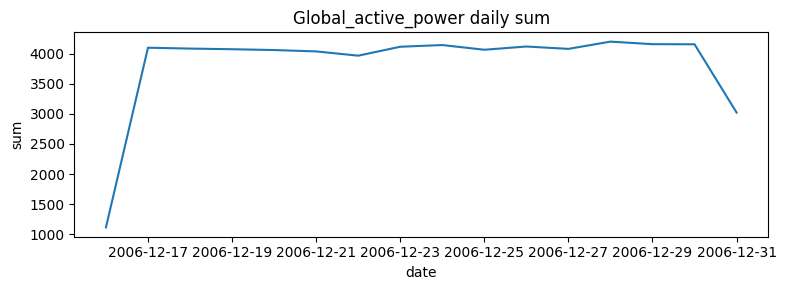

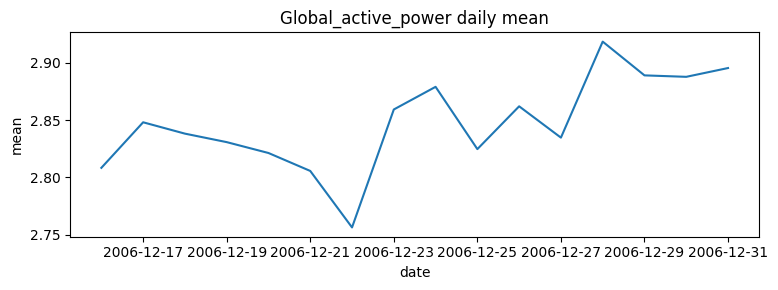

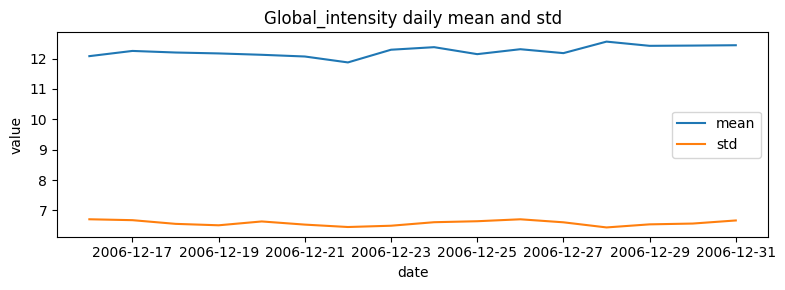

In [6]:
# To-Do: visualize daily aggregations
plot_daily_sum_and_mean(df['Global_active_power'], title_prefix='Global_active_power')
plot_daily_mean_std(df['Global_intensity'], title_prefix='Global_intensity')


# Part 4: Data Preprocessing for LSTM

**Task from the exercise**
Normalize the dataset, split into train and test, and reshape for LSTM input.

**Learning point**  
LSTMs consume sequences with shape [batch, time, features]. You must build sliding windows. Use a lookback window and predict the next step.

![image.png](https://github.com/user-attachments/assets/be3e815f-2aff-4e8d-ac48-eca27b1c729c)

**PREFILLED**  
Windowing helpers and a train test split by time.

In [7]:
# PREFILLED: just execute
from sklearn.preprocessing import MinMaxScaler

def make_windows(arr_2d, window=48, horizon=1):
    X, y = [], []
    for i in range(len(arr_2d) - window - horizon + 1):
        X.append(arr_2d[i:i+window])
        y.append(arr_2d[i+window:i+window+horizon, 0])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    return X, y

def time_train_test_split(df, split_ratio=0.8):
    n = len(df)
    k = int(n * split_ratio)
    return df.iloc[:k].copy(), df.iloc[k:].copy()

feat_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity',
             'Sub_metering_1','Sub_metering_2','Sub_metering_3']
df_feats = df[feat_cols].copy()

df_tr, df_te = time_train_test_split(df_feats, split_ratio=0.8)

scaler = MinMaxScaler()
tr_scaled = scaler.fit_transform(df_tr.values)
te_scaled = scaler.transform(df_te.values)

WINDOW = 48
HORIZON = 1
X_tr, y_tr = make_windows(tr_scaled, window=WINDOW, horizon=HORIZON)
X_te, y_te = make_windows(te_scaled, window=WINDOW, horizon=HORIZON)

print('Train windows:', X_tr.shape, 'Train targets:', X_tr.shape)
print('Test windows:', X_te.shape, 'Test targets:', X_te.shape)

Train windows: (17232, 48, 7) Train targets: (17232, 48, 7)
Test windows: (4272, 48, 7) Test targets: (4272, 48, 7)


We predict Global_active_power as our target variable because it represents the total active household electrical power consumption. In our make_windows function helper, this column maps directly to index 0 of our feature matrix arr_2d and matches the structured target vector slices. We did not change feat_cols, maintaining all 7 electrical attributes to leverage multivariate relationships for the lookback window.

# Part 5: Building an LSTM Model

**Task from the exercise**
Import the libraries, define the LSTM architecture, and compile with a suitable loss and optimizer.

**To-Do (code):** Build a small LSTM with one or two LSTM layers and a Dense output of size `HORIZON`. Use `mse` loss and `adam` optimizer. Print `model.summary()`.

In [8]:
# To-Do: define and compile the LSTM
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(WINDOW, X_tr.shape[-1])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(HORIZON),
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

# Part 6: Training and Evaluating the LSTM Model

**Task from the exercise**
Train the model, evaluate on the test set, and plot training and validation loss.

**PREFILLED**  
Callbacks and plotting helper. You supply the model and data in the To-Do cell.

In [9]:
# PREFILLED: just execute
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=10, batch=256):
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    h = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=epochs, batch_size=batch, callbacks=[es, rl], verbose=2)
    plt.figure(figsize=(6,4))
    plt.plot(h.history['loss'], label='loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.tight_layout(); plt.show()
    return h

**To-Do (code):** Train and evaluate. Report final test MAE and MSE.

Epoch 1/15
68/68 - 8s - 120ms/step - loss: 0.1228 - mae: 0.2871 - val_loss: 0.0853 - val_mae: 0.2515 - learning_rate: 0.0010
Epoch 2/15
68/68 - 6s - 92ms/step - loss: 0.0850 - mae: 0.2514 - val_loss: 0.0845 - val_mae: 0.2508 - learning_rate: 0.0010
Epoch 3/15
68/68 - 5s - 74ms/step - loss: 0.0844 - mae: 0.2507 - val_loss: 0.0840 - val_mae: 0.2503 - learning_rate: 0.0010
Epoch 4/15
68/68 - 5s - 80ms/step - loss: 0.0840 - mae: 0.2504 - val_loss: 0.0838 - val_mae: 0.2500 - learning_rate: 0.0010
Epoch 5/15
68/68 - 10s - 147ms/step - loss: 0.0838 - mae: 0.2502 - val_loss: 0.0837 - val_mae: 0.2500 - learning_rate: 0.0010
Epoch 6/15
68/68 - 6s - 92ms/step - loss: 0.0836 - mae: 0.2499 - val_loss: 0.0836 - val_mae: 0.2499 - learning_rate: 0.0010
Epoch 7/15
68/68 - 5s - 74ms/step - loss: 0.0837 - mae: 0.2500 - val_loss: 0.0844 - val_mae: 0.2510 - learning_rate: 0.0010
Epoch 8/15
68/68 - 6s - 95ms/step - loss: 0.0835 - mae: 0.2499 - val_loss: 0.0839 - val_mae: 0.2504 - learning_rate: 5.0000e-04
E

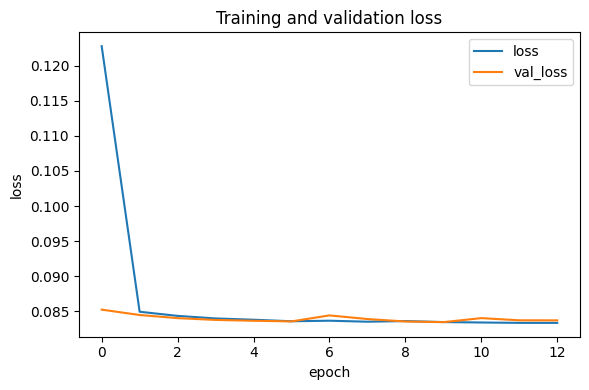

{'test_mse': 0.08347779512405396, 'test_mae': 0.24981047213077545}


In [10]:
# To-Do: train and evaluate
hist = fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=15, batch=256)
eval_mse, eval_mae = model.evaluate(X_te, y_te, verbose=0)
print({'test_mse': float(eval_mse), 'test_mae': float(eval_mae)})
